# PyTorch neural networks — Solutions

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Part A: Regression

### Data

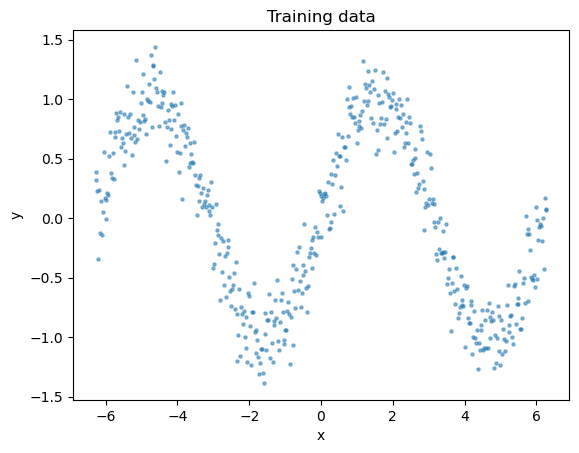

In [2]:
torch.manual_seed(42)

N = 500
x_train = torch.linspace(-2 * np.pi, 2 * np.pi, N).unsqueeze(1)
y_train = torch.sin(x_train) + 0.2 * torch.randn(N, 1)

plt.scatter(x_train.numpy(), y_train.numpy(), s=5, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training data")
plt.show()

### Exercise 1: Define the network

In [3]:
class SineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 32)
        self.layer2 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

### Exercise 2: Train

In [4]:
model = SineNet()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
for epoch in range(2000):
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

### Exercise 3: Visualize

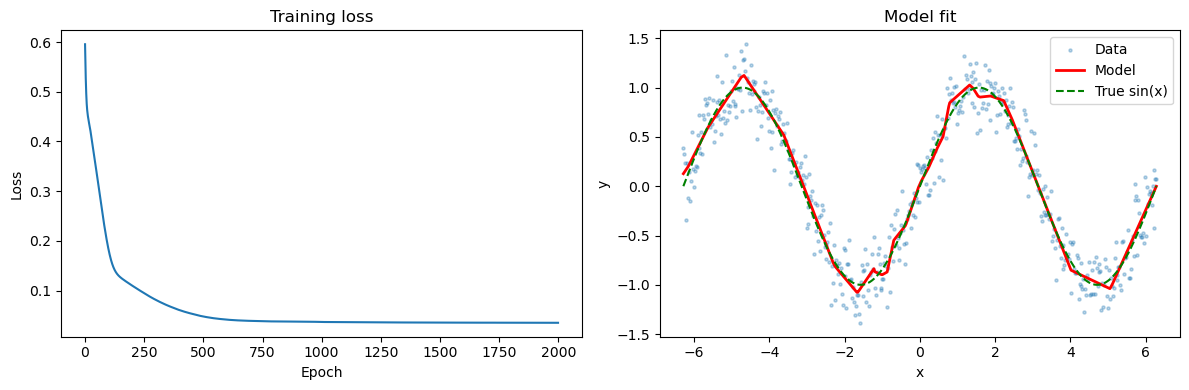

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training loss")

with torch.no_grad():
    y_pred = model(x_train).numpy()

ax2.scatter(x_train.numpy(), y_train.numpy(), s=5, alpha=0.3, label="Data")
ax2.plot(x_train.numpy(), y_pred, color="red", linewidth=2, label="Model")
ax2.plot(
    x_train.numpy(), np.sin(x_train.numpy()), "--", color="green", label="True sin(x)"
)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()
ax2.set_title("Model fit")

plt.tight_layout()
plt.show()

## Part B: Classification

### Data

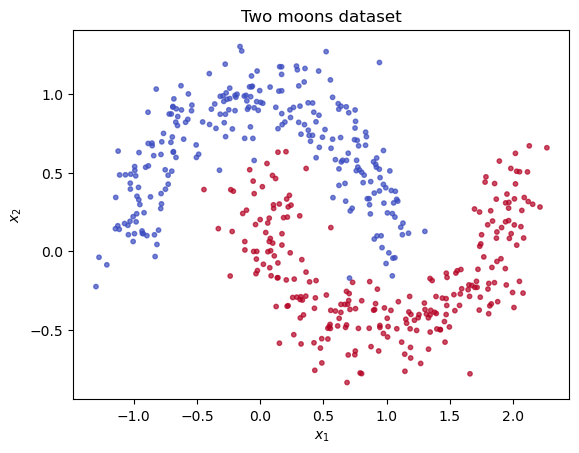

In [6]:
def make_moons(n_samples=500, noise=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_half = n_samples // 2
    theta1 = np.linspace(0, np.pi, n_half)
    x1 = np.column_stack([np.cos(theta1), np.sin(theta1)])
    theta2 = np.linspace(0, np.pi, n_samples - n_half)
    x2 = np.column_stack([1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5])
    X = np.vstack([x1, x2]) + noise * rng.standard_normal((n_samples, 2))
    y = np.hstack([np.zeros(n_half), np.ones(n_samples - n_half)])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(
        y, dtype=torch.float32
    ).unsqueeze(1)


X_train, y_train = make_moons(n_samples=500, noise=0.15)

plt.scatter(
    X_train[:, 0], X_train[:, 1], c=y_train.squeeze(), cmap="coolwarm", s=10, alpha=0.7
)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Two moons dataset")
plt.show()

### Exercise 4: Classifier

In [7]:
class MoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 32)
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

### Exercise 5: Train

In [8]:
model = MoonClassifier()
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

losses = []
for epoch in range(1000):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

### Exercise 6: Decision boundary

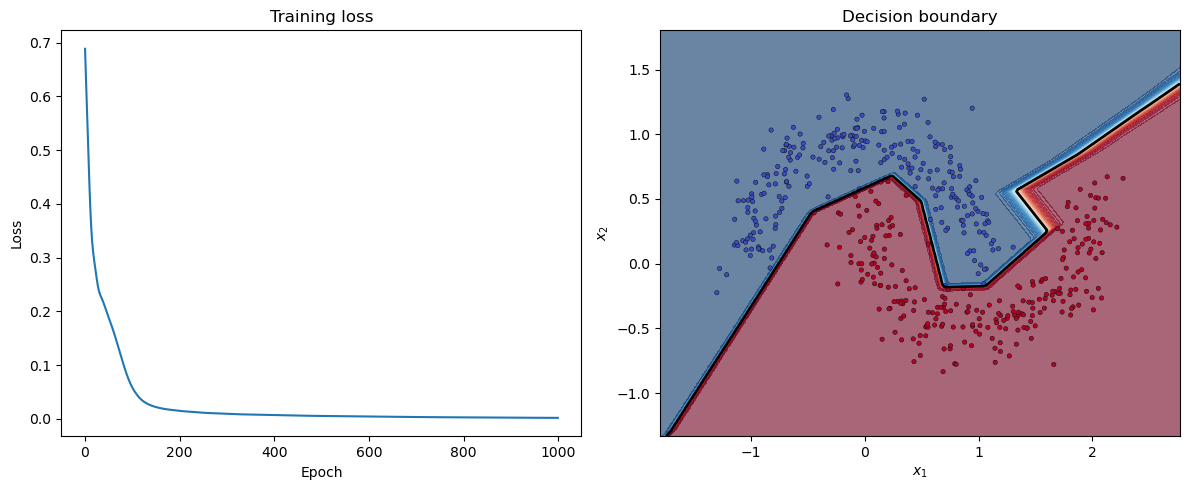

In [9]:
def plot_classification_result(model, X_train, y_train, losses):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(losses)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training loss")

    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200),
    )
    grid = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

    with torch.no_grad():
        probs = model(grid).numpy().reshape(xx.shape)

    ax2.contourf(xx, yy, probs, levels=50, cmap="RdBu_r", alpha=0.6)
    ax2.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)
    ax2.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train.squeeze(),
        cmap="coolwarm",
        s=10,
        edgecolors="k",
        linewidth=0.3,
    )
    ax2.set_xlabel("$x_1$")
    ax2.set_ylabel("$x_2$")
    ax2.set_title("Decision boundary")

    plt.tight_layout()
    plt.show()


plot_classification_result(model, X_train, y_train, losses)